<a href="https://colab.research.google.com/github/Abeldb11/JEPA/blob/main/JEPA_F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
model = model.to(device)

# Freeze
for param in model.parameters():
    param.requires_grad = False

# evaluation
model.eval()

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 160MB/s]


VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [ ]:
import torch
from torch import amp
from torchvision import models


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if device.type == 'cpu':
    print("WARNING: You are still on CPU. Go to Runtime > Change runtime type!")

model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1).to(device)
for param in model.parameters():
    param.requires_grad = False
model.eval()

def extract_features_fast(loader, model):
    all_features = []
    all_labels = []

    print(f"Starting extraction on {device}...")

    with torch.no_grad():

        device_type = 'cuda' if torch.cuda.is_available() else 'cpu'

        with amp.autocast(device_type=device_type):
            for i, (images, labels) in enumerate(loader):
                images = images.to(device, non_blocking=True)
                features = model(images)

                all_features.append(features.cpu())
                all_labels.append(labels)

                if (i + 1) % 10 == 0:
                    print(f"Batch {i+1}/{len(loader)} finished...")

    return torch.cat(all_features), torch.cat(all_labels)

Using device: cuda


In [ ]:
import torch
from torch import amp
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, Subset, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cpu':
    print("STOP! You are on CPU. Go to Runtime > Change runtime type to GPU!")

model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1).to(device)
for param in model.parameters():
    param.requires_grad = False
model.eval()
print("Model loaded and frozen.")

Using device: cuda
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 126MB/s]


Model loaded and frozen.


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

full_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_dataset = Subset(full_train, torch.arange(5000))
train_loader = DataLoader(train_dataset, batch_size=128, num_workers=2, pin_memory=True)

def extract_features(loader, model):
    all_features, all_labels = [], []
    print(f"Extracting features on {device}...")
    with torch.no_grad():
        with amp.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu'):
            for images, labels in loader:
                images = images.to(device, non_blocking=True)
                features = model(images)
                all_features.append(features.cpu())
                all_labels.append(labels)
    return torch.cat(all_features), torch.cat(all_labels)

X_train, y_train = extract_features(train_loader, model)


cached_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)

100%|██████████| 170M/170M [01:32<00:00, 1.84MB/s]


Extracting features on cuda...


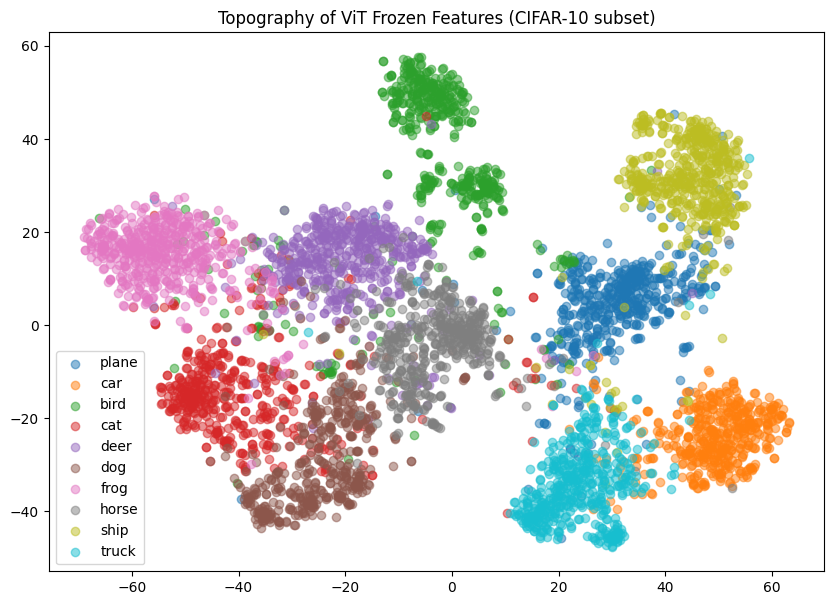

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

X_train_fix = X_train.to(torch.float32)
y_train_fix = y_train.to(torch.long)


cached_loader = DataLoader(TensorDataset(X_train_fix, y_train_fix), batch_size=64, shuffle=True)

probe = torch.nn.Linear(X_train_fix.shape[1], 10).to(device)
optimizer = torch.optim.Adam(probe.parameters(), lr=1e-3)
criterion = torch.nn.CrossEntropyLoss()

for epoch in range(10):
    for feat, lab in cached_loader:
        feat, lab = feat.to(device), lab.to(device)
        optimizer.zero_grad()
        loss = criterion(probe(feat), lab)
        loss.backward()
        optimizer.step()

tsne = TSNE(n_components=2, random_state=42).fit_transform(X_train_fix.numpy())

plt.figure(figsize=(10, 7))
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for i in range(10):
    mask = y_train_fix.numpy() == i
    plt.scatter(tsne[mask, 0], tsne[mask, 1], label=classes[i], alpha=0.5)

plt.legend()
plt.title("Topography of ViT Frozen Features (CIFAR-10 subset)")
plt.show()